# 14 CEO Short-Termism Contract: Solve, Simulate, Validate

Marinovic-Varas (2019) CEO short-termism model (`docs/models/ceo_contract.md`). Pipeline:
**solve** the HJB (Internet-Appendix FD scheme), **present** `F(z,t)` and the policies `a`
(effort), `m` (manipulation), `sigma_z` (vesting sensitivity), **simulate** a cross-section,
and **validate** (HJB residual, sign/concavity, horizon effect, and a Monte-Carlo match of
mean discounted payoff vs `F(z_0, 0)`).

Figure-1 baseline `r=0.1, gamma=1, sigma=2, kappa=0.3, theta=0.4, g=1, T=10, tau=5`
(`lambda=0`, `phi=4`, derived `C ~ 28.87`). The `(a, sigma_z)` maximisation uses a bounded
grid search; Dirichlet BCs `F(0,t)=0` and absorbing at `z_max`. Solved on `z in [0, 0.30]`,
plotted to 0.25.

In [1]:
from pathlib import Path
import os
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- locate repo root so `src.v2` imports work regardless of launch dir ------
REPO_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "src" / "v2").exists():
        REPO_ROOT = candidate
        break
if REPO_ROOT is None:
    raise RuntimeError("Could not find repo root containing src/v2.")
os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

OUTPUT_ROOT = Path("outputs/notebooks/14_ceo_contract_pipeline")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
FIG_DPI = 150
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

def save_fig(fig, name):
    path = OUTPUT_ROOT / name
    fig.savefig(path, dpi=FIG_DPI, bbox_inches="tight")
    return path

print("repo root:", REPO_ROOT)


repo root: /Users/wangzhaoxuan/Desktop/JPM-TSRL/DL_corp_finance


In [2]:
from src.v2.environments.ceo_contract import (
    CEOContractParams,
    CEOContractGridConfig,
    flow_payoff,
)
from src.v2.solvers.ceo_contract import solve_ceo_contract, _fd_derivatives
from src.v2.simulation.ceo_contract import (
    CEOContractSimulationConfig,
    simulate_ceo_contract_panel,
)

# Figure-1 baseline. C is the closed-form post-retirement cost (Eq. 10), derived.
params = CEOContractParams(
    r=0.10, gamma=1.0, sigma=2.0, kappa=0.30, theta=0.40, g=1.0,
    T=10.0, tau=5.0,
)
# IA grid-search FD scheme: z in [0, 0.30]; (a, sigma_z) control grids set in config.
grid = CEOContractGridConfig(n_z=161, n_t=401)
sim_cfg = CEOContractSimulationConfig(n_paths=5000, seed=20260528)
Z_PLOT = 0.25   # Figure-1 display window

print(f"derived: lambda = {params.lambda_:.4f}  (value-destroying effect of manipulation)")
print(f"derived: phi    = {params.phi:.4f}  (manipulation deterrence coefficient)")
print(f"derived: C      = {params.C:.4f}  (terminal post-retirement cost, Eq. 10)")
print(f"grid: n_z={grid.n_z}, n_t={grid.n_t}, z in {grid.z_bounds}; control grids n_a={grid.n_a}, n_sigma={grid.n_sigma}")

/Users/wangzhaoxuan/Desktop/JPM-TSRL/DL_corp_finance/.venv/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


derived: lambda = 0.0000  (value-destroying effect of manipulation)
derived: phi    = 4.0000  (manipulation deterrence coefficient)
derived: C      = 28.8719  (terminal post-retirement cost, Eq. 10)
grid: n_z=161, n_t=401, z in (0.0, 0.3); control grids n_a=41, n_sigma=81


## 1. Solve the HJB

In [3]:
start = time.perf_counter()
res = solve_ceo_contract(grid, params)
solve_time = time.perf_counter() - start

z = res["grids"]["z"]
t = res["grids"]["t"]
V = res["value"]
pol = res["policy"]
diag = res["diagnostics"]

print(f"solved in {solve_time:.2f}s")
print(f"converged                 : {res['converged']}")
print(f"HJB residual  median/max   : {diag['hjb_residual_median']:.2e} / {diag['hjb_residual_max']:.2e}  (max at the manipulation kink)")
print(f"interior F_zz range        : [{diag['min_interior_fzz']:.1f}, {diag['max_interior_fzz']:.2e}]  (concave: max < 0)")
print(f"F(0,t)=0 enforced          : max|F[:,0]| = {np.abs(V[:, 0]).max():.1e}")
print(f"max |sigma_z|              : {diag['max_abs_sigma_z']:.4f}  (bounded -- no blow-up)")
print(f"policy-iter max used       : {diag['max_policy_iter_used']};  steps not converged: {diag['n_steps_not_converged']}")

solved in 5.47s
converged                 : True
HJB residual  median/max   : 4.59e-04 / 2.23e-02  (max at the manipulation kink)
interior F_zz range        : [-192742.0, -9.68e+00]  (concave: max < 0)
F(0,t)=0 enforced          : max|F[:,0]| = 0.0e+00
max |sigma_z|              : 0.0798  (bounded -- no blow-up)
policy-iter max used       : 5;  steps not converged: 0


## 2. Value and policy surfaces

3D surfaces of `F`, `a`, `m`, `sigma_z` over `(z, t)` (X = time, Y = duration).

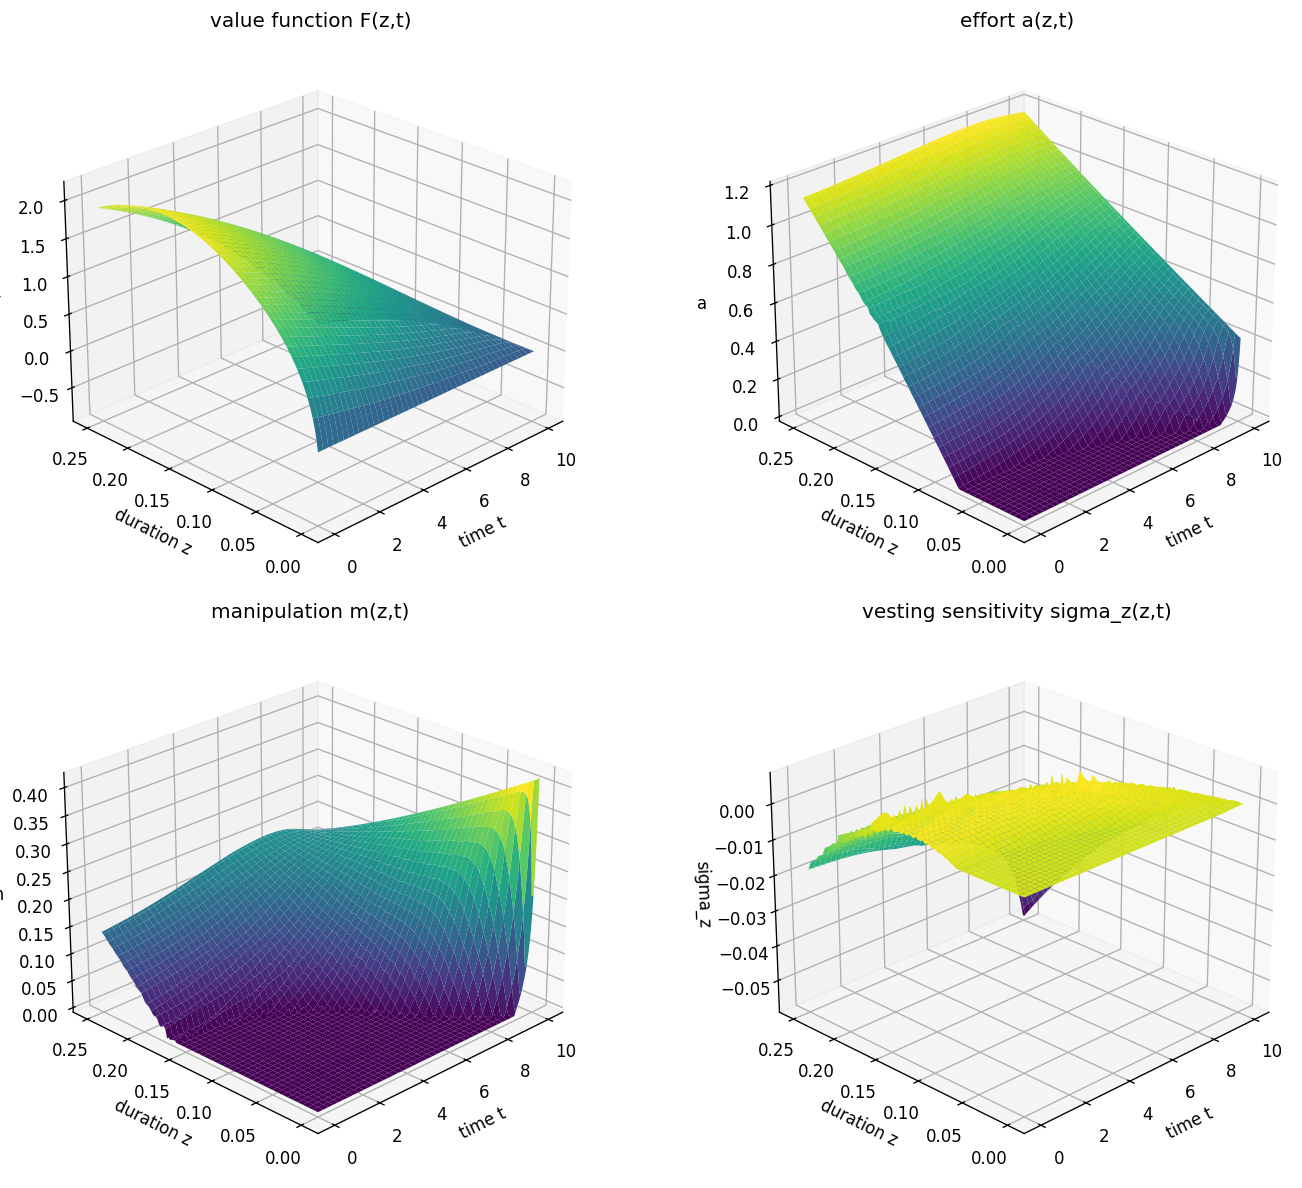

max interior F_zz over all t = -9.684e+00  (<0 => concave everywhere)


In [4]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers the 3d projection)

zmask = z <= Z_PLOT
zp = z[zmask]
ZZ, TT = np.meshgrid(zp, t)  # display window; arrays are (n_t, n_z_plot)
surfaces = [
    ("F", "value function F(z,t)", V),
    ("a", "effort a(z,t)", pol["a"]),
    ("m", "manipulation m(z,t)", pol["m"]),
    ("sigma_z", "vesting sensitivity sigma_z(z,t)", pol["sigma_z"]),
]
fig = plt.figure(figsize=(13, 10))
for k, (zlabel, title, data) in enumerate(surfaces):
    ax = fig.add_subplot(2, 2, k + 1, projection="3d")
    ax.plot_surface(TT, ZZ, data[:, zmask], cmap="viridis", linewidth=0, antialiased=True)
    ax.set_xlabel("time t"); ax.set_ylabel("duration z"); ax.set_zlabel(zlabel)
    ax.set_title(title)
    ax.view_init(elev=25, azim=-135)
fig.tight_layout(); save_fig(fig, "surfaces_3d.png"); plt.show()

# concavity check across all time levels (full domain)
maxfzz = max(_fd_derivatives(V[n], res["grids"]["dz"])[2][1:-1].max() for n in range(len(t)))
print(f"max interior F_zz over all t = {maxfzz:.3e}  (<0 => concave everywhere)")

## 3. Policy slices

Columns `a`, `m`, `sigma_z`. Top row: vs `z` at median `t`. Bottom row: vs `t` at median `z`.

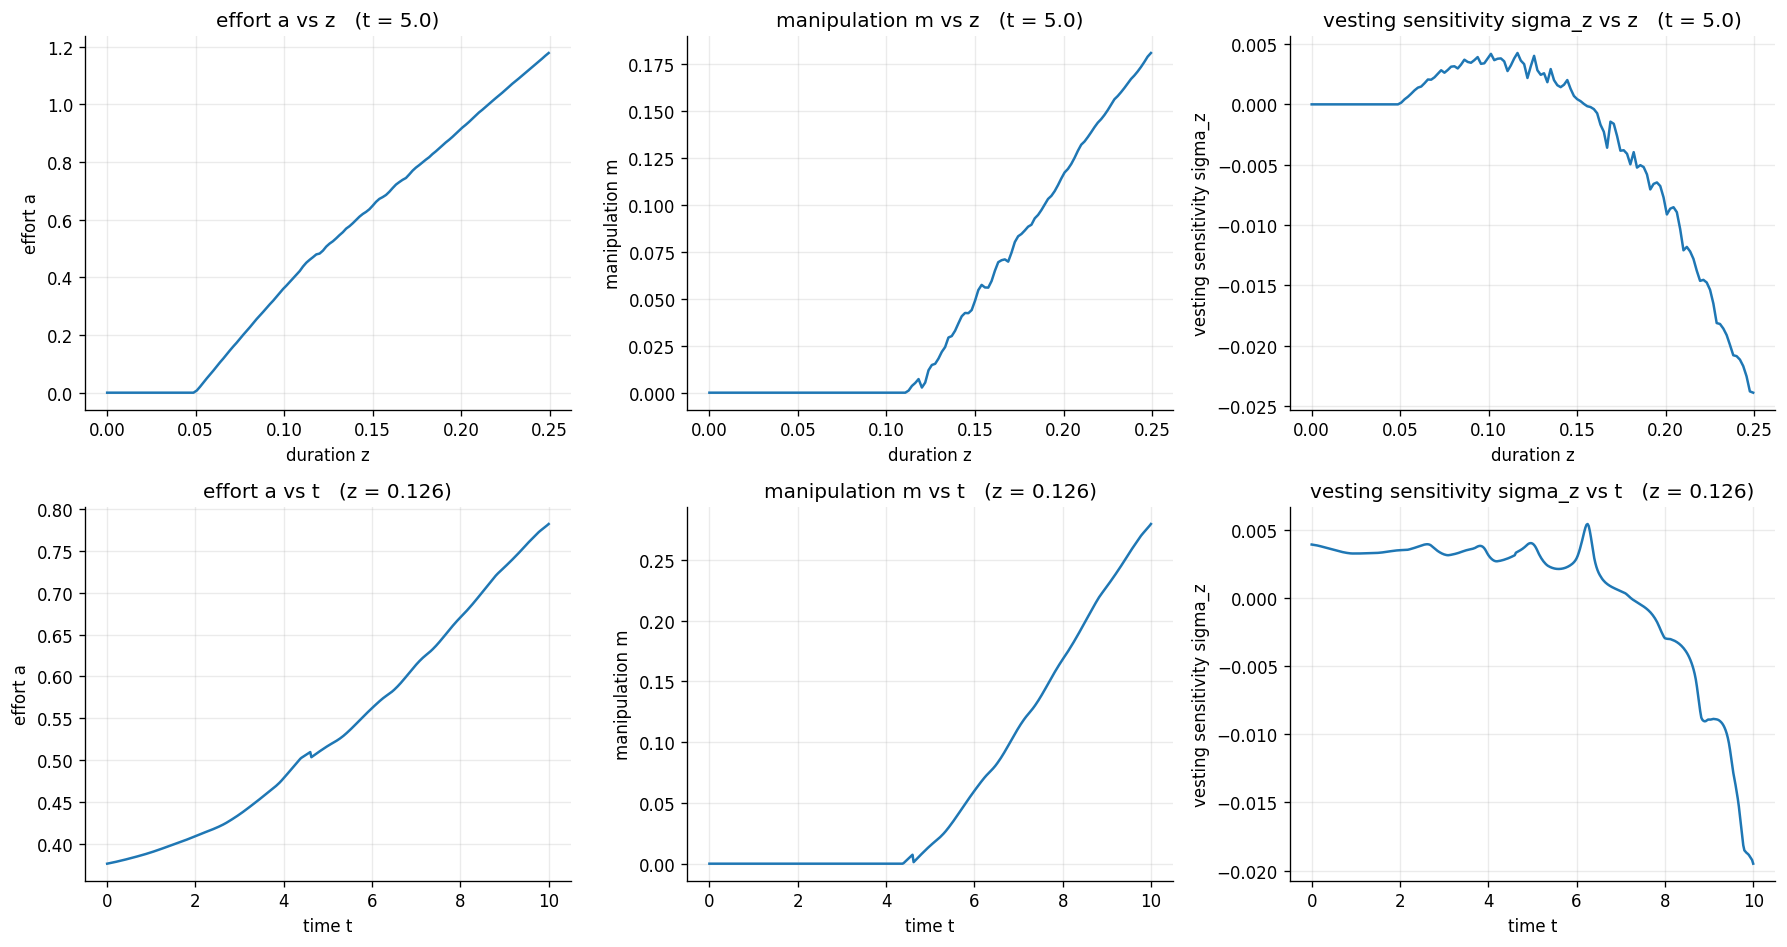

In [5]:
zmask = z <= Z_PLOT
zp = z[zmask]
it_med = len(t) // 2                              # median time index (t = T/2)
iz_med = int(np.argmin(np.abs(z - 0.5 * Z_PLOT))) # median of the display window
t_med, z_med = float(t[it_med]), float(z[iz_med])

keys = [("a", "effort a"), ("m", "manipulation m"), ("sigma_z", "vesting sensitivity sigma_z")]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for j, (key, label) in enumerate(keys):
    axes[0, j].plot(zp, pol[key][it_med][zmask])     # vs z at median t
    axes[0, j].set_xlabel("duration z"); axes[0, j].set_ylabel(label)
    axes[0, j].set_title(f"{label} vs z   (t = {t_med:.1f})")
    axes[1, j].plot(t, pol[key][:, iz_med])          # vs t at median z
    axes[1, j].set_xlabel("time t"); axes[1, j].set_ylabel(label)
    axes[1, j].set_title(f"{label} vs t   (z = {z_med:.3f})")
fig.tight_layout(); save_fig(fig, "policy_slices.png"); plt.show()

## 4. Simulate a CEO cross-section (Euler-Maruyama)

In [6]:
panel = simulate_ceo_contract_panel(res, params, sim_cfg)
print("panel shape:", panel.shape)
panel.head()


panel shape: (2005000, 9)


,path_id,z0,t,z,a,m,sigma_z,M,X
0,0,0.155751,0.000,0.155751,0.590131,0.0,0.001730,0.0,0.000000
1,0,0.155751,0.025,0.155908,0.591665,0.0,0.001722,0.0,0.095492
2,0,0.155751,0.050,0.155500,0.588732,0.0,0.001802,0.0,-0.461308
3,0,0.155751,0.075,0.155504,0.589082,0.0,0.001793,0.0,-0.541272
4,0,0.155751,0.100,0.155296,0.587676,0.0,0.001919,0.0,-0.855487


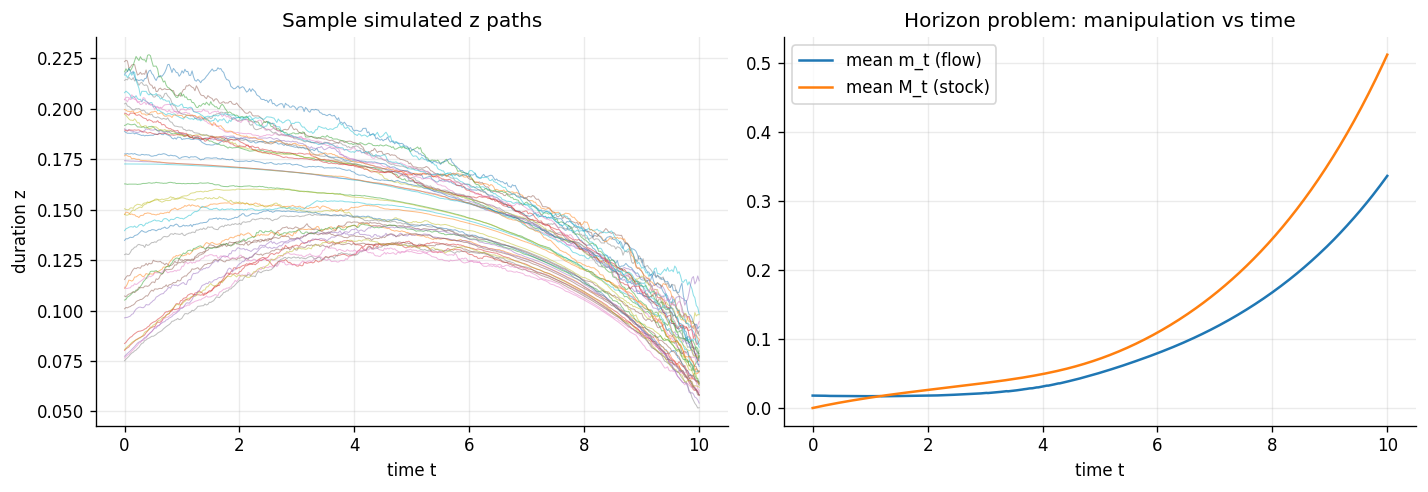

mean manipulation: t=0 -> 0.0180,  t=T -> 0.3359


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# sample z paths
rng = np.random.default_rng(0)
sample_ids = rng.choice(panel["path_id"].unique(), size=40, replace=False)
for pid in sample_ids:
    g = panel[panel["path_id"] == pid]
    axes[0].plot(g["t"], g["z"], lw=0.6, alpha=0.5)
axes[0].set_xlabel("time t"); axes[0].set_ylabel("duration z")
axes[0].set_title("Sample simulated z paths")

# horizon problem: mean manipulation and stock over time
by_t = panel.groupby("t")[["m", "M"]].mean()
axes[1].plot(by_t.index, by_t["m"], label="mean m_t (flow)")
axes[1].plot(by_t.index, by_t["M"], label="mean M_t (stock)")
axes[1].set_xlabel("time t"); axes[1].set_title("Horizon problem: manipulation vs time")
axes[1].legend()
fig.tight_layout(); save_fig(fig, "simulation.png"); plt.show()

print(f"mean manipulation: t=0 -> {by_t['m'].iloc[0]:.4f},  t=T -> {by_t['m'].iloc[-1]:.4f}")


## 5. Validation

(a) independent central-difference HJB residual; (b) Monte-Carlo: mean simulated discounted
payoff vs `F(z_0, 0)`, binned by `z_0`.

In [8]:
# (a) Independent HJB residual (central differences on the solved policies) -- a
# cross-check on top of the solver's own (authoritative, self-consistent) upwind
# residual from section 1. Central differences are unreliable on the thin
# sigma_z-regularised band and the sharp terminal layer, so we report robust
# percentiles rather than the max (which is dominated by those few nodes).
dt = res["grids"]["dt"]
resid = np.full((len(t), len(z)), np.nan)
for n in range(len(t) - 1):
    Fz = np.gradient(V[n], z)
    Fzz = np.gradient(Fz, z)
    mu = (params.r + params.kappa) * z + pol["a"][n] * params.r * params.gamma * (params.sigma * pol["sigma_z"][n] - 1.0)
    pi = flow_payoff(pol["a"][n], pol["m"][n], z, params)
    v_t = (V[n + 1] - V[n]) / dt
    resid[n] = params.r * V[n] - (pi + v_t + mu * Fz + 0.5 * pol["sigma_z"][n] ** 2 * Fzz)

absr = np.abs(resid[:-1, 1:-1])
print(f"solver upwind HJB residual (authoritative)  = {res['hjb_residual']:.3e}")
print(f"central-diff residual  median / 99th pct    = {np.nanmedian(absr):.3e} / {np.nanpercentile(absr, 99):.3e}")
print(f"central-diff residual  max                  = {np.nanmax(absr):.2e}  (confined to the manipulation-kink node)")

solver upwind HJB residual (authoritative)  = 2.229e-02
central-diff residual  median / 99th pct    = 1.085e-03 / 2.852e-01
central-diff residual  max                  = 5.21e+00  (confined to the manipulation-kink node)


overall mean |J - F(z0,0)| = 0.0175
  mean J = 2.0681,  mean F(z0,0) = 2.0596


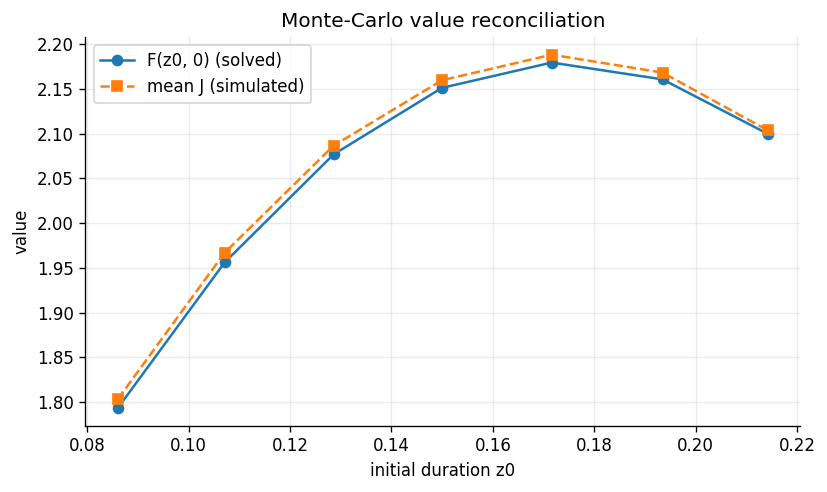

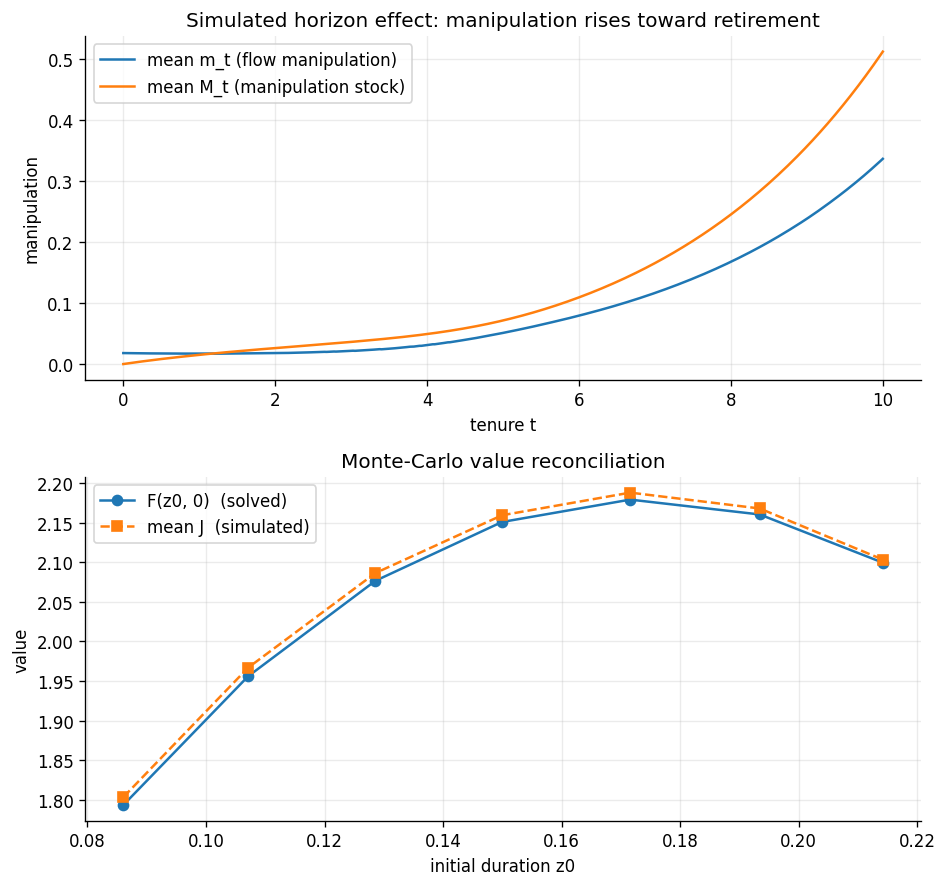

,z0,mean_J,"F(z0,0)",diff
0,0.086046,1.803286,1.793330,0.009956
1,0.107112,1.966918,1.956050,0.010869
2,0.128585,2.086479,2.076686,0.009792
3,0.149945,2.159507,2.151001,0.008506
4,0.171588,2.188130,2.179299,0.008831
5,0.193439,2.168087,2.160520,0.007567
6,0.214213,2.103520,2.099620,0.003900


In [9]:
# (b) Monte-Carlo value reconciliation
n_t = V.shape[0]
disc = np.exp(-params.r * panel["t"].to_numpy())
pi_all = flow_payoff(panel["a"].to_numpy(), panel["m"].to_numpy(), panel["z"].to_numpy(), params)
contrib = (pi_all * disc * dt).reshape(-1, n_t)
flow = contrib[:, :-1].sum(axis=1)
z_paths = panel["z"].to_numpy().reshape(-1, n_t)
z0 = panel["z0"].to_numpy().reshape(-1, n_t)[:, 0]
terminal = np.exp(-params.r * params.T) * (-0.5 * params.C * z_paths[:, -1] ** 2)
J = flow + terminal
F0 = np.interp(z0, z, V[0])

print(f"overall mean |J - F(z0,0)| = {np.mean(np.abs(J - F0)):.4f}")
print(f"  mean J = {J.mean():.4f},  mean F(z0,0) = {F0.mean():.4f}")

# binned comparison
bins = np.linspace(z0.min(), z0.max(), 8)
idx = np.digitize(z0, bins)
rows = []
for b in range(1, len(bins)):
    mask = idx == b
    if mask.sum() > 30:
        rows.append((z0[mask].mean(), J[mask].mean(), F0[mask].mean(), J[mask].mean() - F0[mask].mean()))
recon = pd.DataFrame(rows, columns=["z0", "mean_J", "F(z0,0)", "diff"])

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(recon["z0"], recon["F(z0,0)"], "o-", label="F(z0, 0) (solved)")
ax.plot(recon["z0"], recon["mean_J"], "s--", label="mean J (simulated)")
ax.set_xlabel("initial duration z0"); ax.set_ylabel("value")
ax.set_title("Monte-Carlo value reconciliation"); ax.legend()
fig.tight_layout(); save_fig(fig, "mc_value_reconciliation.png"); plt.show()

# Combined validation figure for the chapter: top = simulated horizon effect,
# bottom = Monte-Carlo value reconciliation.
fig_v, ax_v = plt.subplots(2, 1, figsize=(8, 7.5))
ax_v[0].plot(by_t.index, by_t["m"], label="mean m_t (flow manipulation)")
ax_v[0].plot(by_t.index, by_t["M"], label="mean M_t (manipulation stock)")
ax_v[0].set_xlabel("tenure t"); ax_v[0].set_ylabel("manipulation")
ax_v[0].set_title("Simulated horizon effect: manipulation rises toward retirement")
ax_v[0].legend()
ax_v[1].plot(recon["z0"], recon["F(z0,0)"], "o-", label="F(z0, 0)  (solved)")
ax_v[1].plot(recon["z0"], recon["mean_J"], "s--", label="mean J  (simulated)")
ax_v[1].set_xlabel("initial duration z0"); ax_v[1].set_ylabel("value")
ax_v[1].set_title("Monte-Carlo value reconciliation")
ax_v[1].legend()
fig_v.tight_layout(); save_fig(fig_v, "mc_validation.png"); plt.show()

recon

## 6. Saved artefacts

In [10]:
panel_path = OUTPUT_ROOT / "simulated_panel.parquet"
try:
    panel.to_parquet(panel_path)
except Exception:
    panel_path = OUTPUT_ROOT / "simulated_panel.csv"
    panel.to_csv(panel_path, index=False)

print("saved under", OUTPUT_ROOT, ":")
for p in sorted(OUTPUT_ROOT.glob("*")):
    print("  ", p.name)


saved under outputs/notebooks/14_ceo_contract_pipeline :
   mc_validation.png
   mc_value_reconciliation.png
   policy_slices.png
   simulated_panel.csv
   simulation.png
   surfaces_3d.png
